# FScanpy 

This notebook demonstrates how to use FScanpy with real test data for complete PRF site prediction analysis, including:

## 🎯 Complete Workflow
1. **Load Test Data** - Use built-in real test data
2. **FScanR Analysis** - Identify potential PRF sites from BLASTX results
3. **Sequence Extraction** - Extract sequences around PRF sites
4. **FScanpy Prediction** - Use machine learning models to predict probabilities
5. **Results Visualization** - Generate prediction result plots using built-in plotting functions
6. **Sequence-level Prediction Demo** - Sliding window analysis of complete sequences

## 📊 Data Description
- **blastx_example.xlsx**: Real BLASTX alignment results
- **mrna_example.fasta**: Real mRNA sequence data
- **region_example.csv**: Sample for individual site prediction

## 📚 FScanpy Function Usage Guide

### Core Functions Overview

FScanpy provides several main functions for PRF prediction:

#### 1. `predict_prf()` - Universal Prediction Function


In [ ]:

# Single sequence prediction
results = predict_prf(sequence="ATGCGT...", window_size=3, ensemble_weight=0.4)

# Multiple sequences prediction  
results = predict_prf(sequence=["seq1", "seq2"], window_size=3)

# DataFrame region prediction
results = predict_prf(data=df_with_399bp_column, ensemble_weight=0.4)




#### 2. `plot_prf_prediction()` - Prediction with Visualization


In [ ]:
# Basic plotting
results, fig = plot_prf_prediction(sequence="ATGCGT...")

# Custom parameters
results, fig = plot_prf_prediction(
    sequence="ATGCGT...",
    window_size=1,
    short_threshold=0.65,
    long_threshold=0.8,
    ensemble_weight=0.4,
    save_path="plot.png"
)


#### 3. `PRFPredictor` Class Methods


In [ ]:
#### 3. `PRFPredictor` Class Methods

# Sliding window prediction
results = predictor.predict_sequence(sequence, window_size=3, ensemble_weight=0.4)

# Region prediction
results = predictor.predict_regions(sequences_399bp, ensemble_weight=0.4)

# Single position prediction
result = predictor.predict_single_position(fs_period_33bp, full_seq_399bp)

# Plot prediction
results, fig = predictor.plot_sequence_prediction(sequence)
```

#### 4. Utility Functions

In [ ]:
from FScanpy.utils import fscanr, extract_prf_regions

# Detect PRF sites from BLASTX
prf_sites = fscanr(blastx_df, mismatch_cutoff=10, evalue_cutoff=1e-5)

# Extract sequences around PRF sites
prf_sequences = extract_prf_regions(mrna_file, prf_sites)



### Parameter Guidelines

- **ensemble_weight**: 0.4 (default, balanced), 0.2-0.3 (conservative), 0.7-0.8 (sensitive)
- **window_size**: 1 (detailed), 3 (standard), 6-9 (fast)
- **short_threshold**: 0.1 (default), 0.2-0.3 (stricter filtering)
- **Display thresholds**: 0.3-0.8 for visualization filtering


## 📦 Environment Setup and Data Loading

In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Import FScanpy related modules
from FScanpy import PRFPredictor, predict_prf, plot_prf_prediction
from FScanpy.data import get_test_data_path, list_test_data
from FScanpy.utils import fscanr, extract_prf_regions

print("✅ Environment setup complete!")
print("📋 Available test data:")
list_test_data()

✅ Environment setup complete!
📋 Available test data:


['blastx_example.xlsx',
 'full_seq.xlsx',
 'mrna_example.fasta',
 'region_example.csv']

## 1. Load and Explore Test Data

First, load the real test data provided by FScanpy to understand the data structure.

In [5]:
# Get test data paths
blastx_file = get_test_data_path('blastx_example.xlsx')
mrna_file = get_test_data_path('mrna_example.fasta')
region_file = get_test_data_path('region_example.csv')

print(f"📁 Data file paths:")
print(f"  BLASTX data: {blastx_file}")
print(f"  mRNA sequences: {mrna_file}")
print(f"  Validation regions: {region_file}")

# Load BLASTX data
blastx_data = pd.read_excel(blastx_file)
print(f"\n🧬 BLASTX data overview:")
print(f"  Data shape: {blastx_data.shape}")
print(f"  Column names: {list(blastx_data.columns)}")
print(f"  Unique sequences: {blastx_data['DNA_seqid'].nunique()}")

# Display first few rows
print("\n📊 BLASTX data examples:")
display_cols = ['DNA_seqid', 'Pep_seqid', 'pident', 'length', 'evalue', 'qframe']
print(blastx_data[display_cols].head())

📁 Data file paths:
  BLASTX data: c:\Users\31598\Downloads\bilstm_train\fscanpy-package\FScanpy\data\test_data\blastx_example.xlsx
  mRNA sequences: c:\Users\31598\Downloads\bilstm_train\fscanpy-package\FScanpy\data\test_data\mrna_example.fasta
  Validation regions: c:\Users\31598\Downloads\bilstm_train\fscanpy-package\FScanpy\data\test_data\region_example.csv

🧬 BLASTX data overview:
  Data shape: (1000, 14)
  Column names: ['DNA_seqid', 'Pep_seqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore', 'qframe', 'sframe']
  Unique sequences: 704

📊 BLASTX data examples:
      DNA_seqid          Pep_seqid  pident  length        evalue  qframe
0  MSTRG.9998.1  CAMPEP_0196994412   68.27     104  1.000000e-33       2
1  MSTRG.9996.1  CAMPEP_0197017426   49.16     297  3.000000e-79       2
2  MSTRG.9994.1  CAMPEP_0197009206   98.31     354  0.000000e+00       2
3  MSTRG.9993.1  CAMPEP_0168331218   51.67      60  2.000000e-37       2
4  MSTRG.

In [6]:
# Load validation region data
region_data = pd.read_csv(region_file)
print(f"🎯 Validation region data overview:")
print(f"  Data shape: {region_data.shape}")
print(f"  Column names: {list(region_data.columns)}")
print(f"  Data sources: {region_data['source'].value_counts().to_dict()}")

print("\n📋 Validation region data examples:")
display_cols = ['fs_position', 'DNA_seqid', 'label', 'source', 'FS_type']
print(region_data[display_cols].head())

# Statistical analysis
print(f"\n📈 Label distribution:")
print(region_data['label'].value_counts())
print(f"\n🔬 FS type distribution:")
print(region_data['FS_type'].value_counts())

🎯 Validation region data overview:
  Data shape: (3, 8)
  Column names: ['FS_period', '399bp', 'fs_position', 'DNA_seqid', 'label', 'source', 'FS_type', 'dataset']
  Data sources: {'EUPLOTES': 3}

📋 Validation region data examples:
   fs_position      DNA_seqid  label    source   FS_type
0         16.0  MSTRG.18491.1      0  EUPLOTES  negative
1         16.0   MSTRG.4662.1      0  EUPLOTES  negative
2         16.0  MSTRG.14742.1      0  EUPLOTES  negative

📈 Label distribution:
label
0    3
Name: count, dtype: int64

🔬 FS type distribution:
FS_type
negative    3
Name: count, dtype: int64


## 2. FScanR Analysis - Identify Potential PRF Sites from BLASTX

Use the FScanR algorithm to analyze BLASTX results and identify potential programmed ribosomal frameshift sites.

In [7]:
# Run FScanR analysis
print("🔍 Running FScanR analysis...")
print("Parameter settings: mismatch_cutoff=10, evalue_cutoff=1e-5, frameDist_cutoff=10")

fscanr_results = fscanr(
    blastx_data,
    mismatch_cutoff=10,
    evalue_cutoff=1e-5,
    frameDist_cutoff=10
)

print(f"\n✅ FScanR analysis complete!")
print(f"Number of potential PRF sites detected: {len(fscanr_results)}")

if len(fscanr_results) > 0:
    print(f"\n📊 FScanR results overview:")
    print(f"  Column names: {list(fscanr_results.columns)}")
    print(f"  Number of sequences involved: {fscanr_results['DNA_seqid'].nunique()}")
    print(f"  Strand orientation distribution: {fscanr_results['Strand'].value_counts().to_dict()}")
    print(f"  FS type distribution: {fscanr_results['FS_type'].value_counts().to_dict()}")
    
    print("\n🎯 FScanR results examples:")
    print(fscanr_results.head())
else:
    print("⚠️ No PRF sites detected, may need to adjust parameters")

🔍 Running FScanR analysis...
Parameter settings: mismatch_cutoff=10, evalue_cutoff=1e-5, frameDist_cutoff=10

✅ FScanR analysis complete!
Number of potential PRF sites detected: 16

📊 FScanR results overview:
  Column names: ['DNA_seqid', 'FS_start', 'FS_end', 'Pep_seqid', 'Pep_FS_start', 'Pep_FS_end', 'FS_type', 'Strand']
  Number of sequences involved: 12
  Strand orientation distribution: {'+': 11, '-': 5}
  FS type distribution: {1: 9, -1: 7}

🎯 FScanR results examples:
      DNA_seqid  FS_start  FS_end          Pep_seqid  Pep_FS_start  \
0  MSTRG.9380.1      3797    3802  CAMPEP_0197017206          1137   
1  MSTRG.9582.1       302     304  CAMPEP_0197003180           214   
2   MSTRG.961.1      1536    1533  CAMPEP_0197017908           590   
3  MSTRG.9622.1       555     560  CAMPEP_0197016962           182   
4  MSTRG.9648.1       801     803  CAMPEP_0197001104           257   

   Pep_FS_end  FS_type Strand  
0        1138        1      +  
1         214        1      +  
2   

## 3. Sequence Extraction - Extract Sequences Around PRF Sites

Extract sequence fragments around PRF sites identified by FScanR from mRNA sequences.

In [8]:
# Extract sequences around PRF sites
if len(fscanr_results) > 0:
    print("📝 Extracting sequences around PRF sites from mRNA sequences...")
    
    prf_sequences = extract_prf_regions(
        mrna_file=mrna_file,
        prf_data=fscanr_results
    )
    
    print(f"\n✅ Sequence extraction complete!")
    print(f"Number of successfully extracted sequences: {len(prf_sequences)}")
    
    if len(prf_sequences) > 0:
        print(f"\n📏 Sequence length validation:")
        seq_lengths = prf_sequences['399bp'].str.len()
        print(f"  399bp sequence length distribution: {seq_lengths.value_counts().to_dict()}")
        print(f"  Average length: {seq_lengths.mean():.1f}")
        
        print("\n🧬 Extracted sequence examples:")
        for i, row in prf_sequences.head(3).iterrows():
            print(f"Sequence {i+1}: {row['DNA_seqid']}")
            print(f"  FS position: {row['FS_start']}-{row['FS_end']}")
            print(f"  Strand orientation: {row['Strand']}")
            print(f"  FS type: {row['FS_type']}")
            print(f"  Sequence fragment: {row['399bp'][:50]}...{row['399bp'][-20:]}")
            print()
    else:
        print("❌ Sequence extraction failed")
else:
    print("⚠️ Skipping sequence extraction - no FScanR results")
    prf_sequences = pd.DataFrame()

📝 Extracting sequences around PRF sites from mRNA sequences...

✅ Sequence extraction complete!
Number of successfully extracted sequences: 16

📏 Sequence length validation:
  399bp sequence length distribution: {399: 16}
  Average length: 399.0

🧬 Extracted sequence examples:
Sequence 1: MSTRG.9380.1
  FS position: 3797-3802
  Strand orientation: +
  FS type: 1
  Sequence fragment: AAGGAGTTTGAAGAAGAACAGGAAAAACAAGAGAAAGAGAGAAAGGAGAA...NNNNNNNNNNNNNNNNNNNN

Sequence 2: MSTRG.9582.1
  FS position: 302-304
  Strand orientation: +
  FS type: 1
  Sequence fragment: ATCAAGCTGATTAGAGATGGAGGGGGAGGTGTGTTCAATAATATATCTAC...AGTCAACTTCCAGTCCAACA

Sequence 3: MSTRG.961.1
  FS position: 1536-1533
  Strand orientation: -
  FS type: -1
  Sequence fragment: ATGCTACTTTGGGAGAGAAAATTAACTGGGGAGAACTTGCATATGATTCT...ACAAATATTTCTCTAATTCA



## 4. FScanpy Prediction - Machine Learning Model Analysis

Use FScanpy's machine learning models to predict PRF probabilities for the extracted sequences.

In [9]:
# Initialize predictor
predictor = PRFPredictor()
print("🤖 FScanpy predictor initialization complete")

# Predict FScanR identified sequences
if len(prf_sequences) > 0:
    print(f"\n🎯 Predicting {len(prf_sequences)} sequences identified by FScanR...")
    
    fscanr_predictions = predictor.predict_regions(
        sequences=prf_sequences['399bp'],
        ensemble_weight=0.4  # Balanced configuration
    )
    
    # Merge results
    fscanr_predictions = pd.concat([
        prf_sequences.reset_index(drop=True),
        fscanr_predictions.reset_index(drop=True)
    ], axis=1)
    
    print("\n📊 FScanR+FScanpy prediction results:")
    result_cols = ['DNA_seqid', 'FS_start', 'FS_type', 'Short_Probability', 'Long_Probability', 'Ensemble_Probability']
    print(fscanr_predictions[result_cols].head())

c:\Users\31598\Downloads\bilstm_train\fscanpy-package\FScanpy\predictor.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
c:\Users\31598\Downloads\bilstm_train\fscanpy-package\FScanpy\predictor.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be load

🤖 FScanpy predictor initialization complete

🎯 Predicting 16 sequences identified by FScanR...

📊 FScanR+FScanpy prediction results:
      DNA_seqid  FS_start  FS_type  Short_Probability  Long_Probability  \
0  MSTRG.9380.1      3797        1           0.037606          0.000000   
1  MSTRG.9582.1       302        1           0.694967          0.887768   
2   MSTRG.961.1      1536       -1           0.455221          0.771689   
3  MSTRG.9622.1       555        1           0.884886          0.860776   
4  MSTRG.9648.1       801        1           0.909365          0.914514   

   Ensemble_Probability  
0              0.000000  
1              0.810648  
2              0.645102  
3              0.870420  
4              0.912454  


In [10]:
# Predict validation region data
print(f"\n🧪 Predicting {len(region_data)} validation regions...")

validation_predictions = predict_prf(
    data=region_data.rename(columns={'399bp': 'Long_Sequence'}),
    ensemble_weight=0.4
)

print("\n📊 Validation region prediction results:")
result_cols = ['DNA_seqid', 'label', 'source', 'Short_Probability', 'Long_Probability', 'Ensemble_Probability']
print(validation_predictions[result_cols].head())


🧪 Predicting 3 validation regions...

📊 Validation region prediction results:
       DNA_seqid  label    source  Short_Probability  Long_Probability  \
0  MSTRG.18491.1      0  EUPLOTES           0.004103          0.000000   
1   MSTRG.4662.1      0  EUPLOTES           0.430871          0.116010   
2  MSTRG.14742.1      0  EUPLOTES           0.760868          0.734617   

   Ensemble_Probability  
0              0.000000  
1              0.241954  
2              0.745117  


c:\Users\31598\Downloads\bilstm_train\fscanpy-package\FScanpy\predictor.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_locatio

## 5. Sequence-level Prediction and Visualization

Select a specific mRNA sequence and use the built-in plot_prf_prediction function for complete sliding window prediction and visualization.

🧬 Selected demonstration sequence: MSTRG.9127.1
Sequence length: 256 bp
First 100bp of sequence: TGGCCTTCTTACTTGGAAGTCCCCAAGGATCATCTTGGCCATCCTTGCTTTCTTCATGGCTAGATTCTACCTCCTCCCATAATTGTGTGAAACAAGTAAC...

🎯 Using plot_prf_prediction for sequence prediction and visualization...


c:\Users\31598\Downloads\bilstm_train\fscanpy-package\FScanpy\predictor.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_locatio

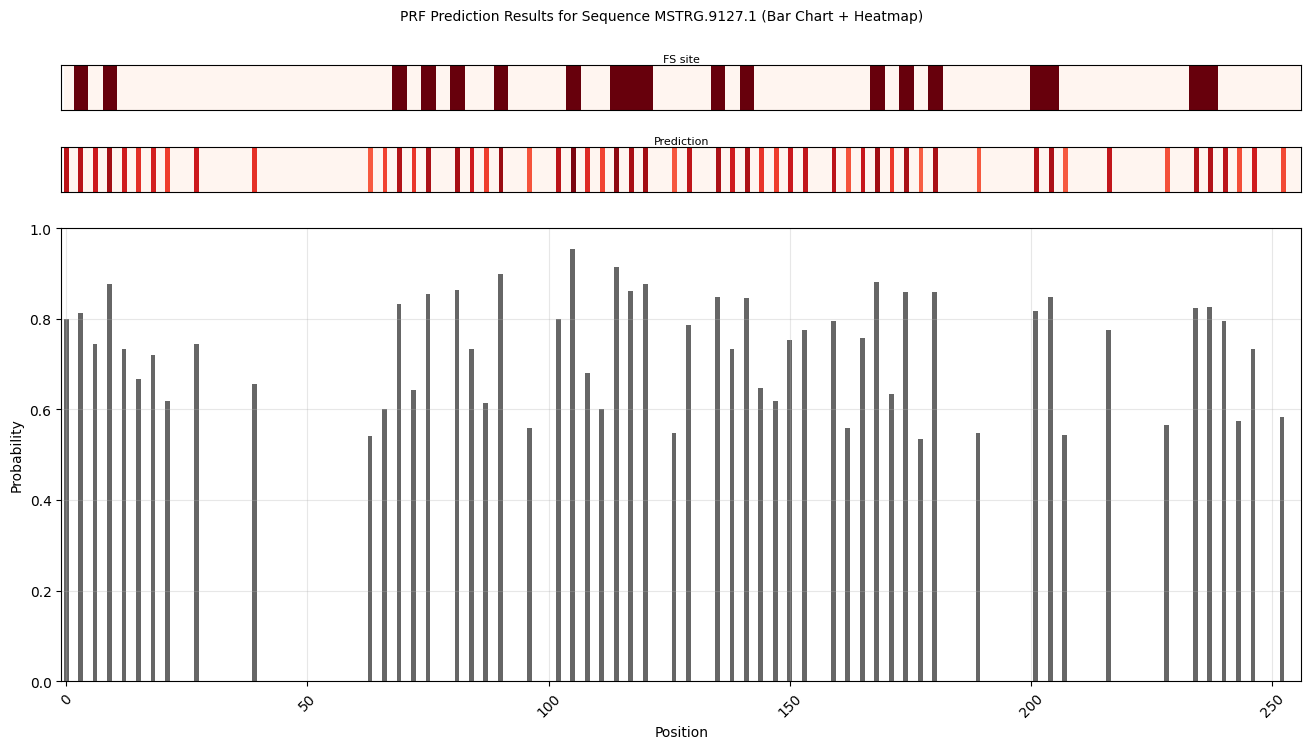


📊 Sequence prediction result statistics:
  Total predicted sites: 85
  High probability sites (>0.8): 19
  Medium probability sites (0.4-0.8): 45
  Highest prediction probability: 0.954


In [11]:
# Select a sequence for demonstration
from Bio import SeqIO

# Read the first mRNA sequence for demonstration
mrna_sequences = list(SeqIO.parse(mrna_file, "fasta"))
demo_seq = mrna_sequences[0]  # Select the first sequence

print(f"🧬 Selected demonstration sequence: {demo_seq.id}")
print(f"Sequence length: {len(demo_seq.seq)} bp")
print(f"First 100bp of sequence: {str(demo_seq.seq)[:100]}...")

# Use built-in plot_prf_prediction function for prediction and visualization
print(f"\n🎯 Using plot_prf_prediction for sequence prediction and visualization...")

sequence_results, fig = plot_prf_prediction(
    sequence=str(demo_seq.seq),
    window_size=3,
    short_threshold=0.2,
    long_threshold=0.2,
    ensemble_weight=0.6,
    title=f"PRF Prediction Results for Sequence {demo_seq.id} (Bar Chart + Heatmap)",
    figsize=(16, 8),
    dpi=150
)

plt.show()

print(f"\n📊 Sequence prediction result statistics:")
print(f"  Total predicted sites: {len(sequence_results)}")
print(f"  High probability sites (>0.8): {(sequence_results['Ensemble_Probability'] > 0.8).sum()}")
print(f"  Medium probability sites (0.4-0.8): {((sequence_results['Ensemble_Probability'] >= 0.4) & (sequence_results['Ensemble_Probability'] <= 0.8)).sum()}")
print(f"  Highest prediction probability: {sequence_results['Ensemble_Probability'].max():.3f}")

In [12]:
# Print top predicted site probabilities
if sequence_results['Ensemble_Probability'].max() > 0.3:
    top_predictions = sequence_results.nlargest(5, 'Ensemble_Probability')
    print(f"\n🔝 Top 5 predicted sites:")
    for i, (_, row) in enumerate(top_predictions.iterrows(), 1):
        print(f"  {i}. Position {row['Position']}: ")
        print(f"     - Short probability: {row['Short_Probability']:.3f}")
        print(f"     - Long probability: {row['Long_Probability']:.3f}")
        print(f"     - Ensemble probability: {row['Ensemble_Probability']:.3f}")
        print(f"     - Codon: {row['Codon']}")
else:
    print("\n💡 No high-probability PRF sites detected in this sequence")

print("\n📊 Visualization analysis complete!")
print("The chart contains heatmaps and bar charts showing the PRF prediction probability distribution across the entire sequence.")


🔝 Top 5 predicted sites:
  1. Position 105: 
     - Short probability: 0.923
     - Long probability: 1.000
     - Ensemble probability: 0.954
     - Codon: ACT
  2. Position 114: 
     - Short probability: 0.858
     - Long probability: 1.000
     - Ensemble probability: 0.915
     - Codon: TAT
  3. Position 90: 
     - Short probability: 0.830
     - Long probability: 1.000
     - Ensemble probability: 0.898
     - Codon: AAC
  4. Position 168: 
     - Short probability: 0.802
     - Long probability: 1.000
     - Ensemble probability: 0.881
     - Codon: CTG
  5. Position 9: 
     - Short probability: 0.797
     - Long probability: 0.998
     - Ensemble probability: 0.877
     - Codon: TAC

📊 Visualization analysis complete!
The chart contains heatmaps and bar charts showing the PRF prediction probability distribution across the entire sequence.


## 📖 Complete Function Reference

### All Available Functions and Methods

#### Core Prediction Functions

**1. `predict_prf(sequence=None, data=None, window_size=3, short_threshold=0.1, ensemble_weight=0.4, model_dir=None)`**
- **Purpose**: Universal prediction function for both sliding window and region-based analysis
- **Input modes**: 
  - Single/multiple sequences → sliding window prediction
  - DataFrame with 'Long_Sequence'/'399bp' column → region prediction
- **Key parameters**:
  - `ensemble_weight`: Short model weight (0.0-1.0, default: 0.4)
  - `window_size`: Scanning step size (default: 3)
  - `short_threshold`: Filtering threshold (default: 0.1)

**2. `plot_prf_prediction(sequence, window_size=3, short_threshold=0.65, long_threshold=0.8, ensemble_weight=0.4, title=None, save_path=None, figsize=(12,8), dpi=300)`**
- **Purpose**: Prediction with built-in visualization (3-subplot layout: FS site heatmap, prediction heatmap, bar chart)
- **Returns**: (prediction_results_df, matplotlib_figure)
- **Visualization features**: 
  - Black bars with alpha=0.6
  - 'Reds' colormap for heatmaps
  - Height ratios [0.1, 0.1, 1] for subplots

#### PRFPredictor Class Methods

**3. Class initialization: `PRFPredictor(model_dir=None)`**
- Loads HistGradientBoosting (short, 33bp) and BiLSTM-CNN (long, 399bp) models
- Uses ensemble weighting for final predictions

**4. `predictor.predict_sequence(sequence, window_size=3, short_threshold=0.1, ensemble_weight=0.4)`**
- **Purpose**: Sliding window analysis of complete sequences
- **Process**: Scans sequence with specified window size, applies both models

**5. `predictor.predict_regions(sequences, short_threshold=0.1, ensemble_weight=0.4)`**
- **Purpose**: Batch prediction for pre-defined 399bp regions
- **Input**: List/Series of 399bp sequences
- **Efficient**: Direct region analysis without sliding window

**6. `predictor.predict_single_position(fs_period, full_seq, short_threshold=0.1, ensemble_weight=0.4)`**
- **Purpose**: Single position analysis
- **Inputs**: 33bp sequence (fs_period) + 399bp sequence (full_seq)
- **Returns**: Dictionary with individual and ensemble probabilities

**7. `predictor.plot_sequence_prediction(...)`** 
- **Purpose**: Class method version of plot_prf_prediction()
- **Same parameters** as standalone function

#### Utility Functions

**8. `fscanr(blastx_output, mismatch_cutoff=10, evalue_cutoff=1e-5, frameDist_cutoff=10)`**
- **Purpose**: Detect PRF sites from BLASTX alignment results
- **Input**: DataFrame with BLASTX columns (qseqid, sseqid, pident, length, mismatch, gapopen, qstart, qend, sstart, send, evalue, bitscore, qframe, sframe)
- **Output**: PRF sites with FS_start, FS_end, FS_type, Strand information

**9. `extract_prf_regions(mrna_file, prf_data)`**
- **Purpose**: Extract 399bp sequences around detected PRF sites
- **Inputs**: FASTA file path + FScanR results DataFrame
- **Handles**: Strand orientation (reverse complement for '-' strand)

#### Data Access Functions

**10. `get_test_data_path(filename)`**
- **Purpose**: Get path to built-in test data files
- **Available files**: 'blastx_example.xlsx', 'mrna_example.fasta', 'region_example.csv'

**11. `list_test_data()`**
- **Purpose**: Display all available test data files

### Usage Pattern Examples

#### Pattern 1: Quick Single Sequence Analysis
```python
from FScanpy import predict_prf, plot_prf_prediction

# Simple prediction
results = predict_prf(sequence="ATGCGT...")

# With visualization  
results, fig = plot_prf_prediction(sequence="ATGCGT...")
```

#### Pattern 2: Batch Sequence Analysis
```python
sequences = ["seq1", "seq2", "seq3"]
results = predict_prf(sequence=sequences, ensemble_weight=0.5)
```

#### Pattern 3: BLASTX Pipeline
```python
from FScanpy.utils import fscanr, extract_prf_regions

# Step 1: Detect PRF sites
prf_sites = fscanr(blastx_df)

# Step 2: Extract sequences
prf_sequences = extract_prf_regions(fasta_file, prf_sites)

# Step 3: Predict probabilities
results = predict_prf(data=prf_sequences)
```

#### Pattern 4: Custom Analysis with PRFPredictor
```python
from FScanpy import PRFPredictor

predictor = PRFPredictor()

# Method chaining for different analysis types
seq_results = predictor.predict_sequence(sequence)
region_results = predictor.predict_regions(sequences_399bp)
single_result = predictor.predict_single_position(seq_33bp, seq_399bp)
```

### Parameter Optimization Guide

**Ensemble Weight Selection:**
- `0.2-0.3`: Conservative (high specificity, favor long model)
- `0.4-0.6`: Balanced (recommended default)
- `0.7-0.8`: Sensitive (high sensitivity, favor short model)

**Window Size Selection:**
- `1`: High resolution, every position (slow but detailed)
- `3`: Standard resolution (balanced speed/detail)  
- `6-9`: Low resolution, faster analysis

**Threshold Guidelines:**
- `short_threshold`: 0.1-0.3 (controls efficiency by filtering low-probability candidates)
- Display thresholds: 0.3-0.8 (controls visualization, higher = cleaner plots)
- Classification threshold: 0.5 (standard binary classification cutoff)

### Output Interpretation

**Main Result Columns:**
- `Short_Probability`: HistGradientBoosting model prediction (0-1)
- `Long_Probability`: BiLSTM-CNN model prediction (0-1)
- `Ensemble_Probability`: **Final prediction** (weighted combination)
- `Position`: Sequence position (sliding window mode)
- `Codon`: Codon at position (sliding window mode)

**Ensemble Probability Interpretation:**
- `> 0.8`: High confidence PRF site
- `0.5-0.8`: Moderate confidence PRF site  
- `0.3-0.5`: Low confidence, worth investigating
- `< 0.3`: Unlikely to be PRF site

### Best Practices

1. **For exploration**: Use `window_size=1, ensemble_weight=0.4`
2. **For screening**: Use `window_size=3, ensemble_weight=0.4, short_threshold=0.2`
3. **For validation**: Use region-based prediction with known sequences
4. **For visualization**: Adjust `short_threshold` and `long_threshold` in plotting functions to control display density

This demo covers all major FScanpy functionalities. For detailed parameter descriptions and advanced usage, please refer to the complete tutorial documentation.
